In [24]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
max_test_accuracy = -1

In [28]:
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [52]:
import os
from sklearn.preprocessing import LabelEncoder
import numpy as np
import torch
from torch.optim import lr_scheduler

In [30]:
# code for spectogram testing(take file input->check whether it is wav or not(webm)->if webm->convert to wav using moviepy->else generate spectrogram and return mel array)
import numpy as np
import matplotlib.pyplot as plt
from moviepy import VideoFileClip
import librosa
N_FFT = 1024
HOP_LEN = 512
def generate_spectrogram(file_path):
    file_path =  "../data/genres_original/" + file_path[:file_path.find(".")] + "/" + file_path
    # some file in data set are corrupted -_-
    try:
        
        if(".wav" not in file_path):
            # Step 1: convert to wav if not in the format
            clip = VideoFileClip(file_path)
            clip.audio.write_audiofile("out_audio.wav")
            file_path="out_audio.wav"
        y, sr = librosa.load(file_path) #sr sample rate
        # some sample smaller than 30s
        print(len(y))
        if len(y) < sr*30:
            y = np.pad(y, (0, int(sr*30) - len(y)))
        y = y[:int(sr*30)]
        # Step 2: do fft over the audio file and convert output to mel scale
        mel_spect = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LEN)
        # # Convert amplitude to decibels so that difference in loudness is distinguishable
        mel_spect = librosa.power_to_db(mel_spect, ref=np.max)
        # getting all values between 0 and 1
        mel_spect = (mel_spect - mel_spect.min()) / (mel_spect.max() - mel_spect.min())
        return mel_spect
    except Exception:
        print(file_path)
        print("Audio corrupt.. skip")
        return None

In [31]:
import os
from sklearn.preprocessing import LabelEncoder
import numpy as np

def preprocess():
    data = "../data/genres_original"
    x = []
    y = []

    # loop over folder and sub-folder
    for genre_folder in os.scandir(data):
        for files in os.scandir(genre_folder):
            # get sample
            sample = files.name
            spectogram = generate_spectrogram(sample)
            # if corrupt then dont add
            if spectogram is not None:
                x.append(spectogram)
                y.append(sample[:sample.find(".")])
    
    # get string to num maping
    mapping = LabelEncoder()
    y = mapping.fit_transform(y)
    mapping = dict(zip(range(len(mapping.classes_)), mapping.classes_))
    x = np.array(x)
    
    
    return x,y,mapping

x,y,mapping = preprocess()

661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
669680

C:\Users\Priyam Patel\AppData\Local\Temp\ipykernel_24396\2370926190.py:18: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path) #sr sample rate
c:\Users\Priyam Patel\PRML-Project\.venv\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


661794
672100
661794
666820
661794
669240
661980
661794
667480
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661794
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661504
661794
661794
661794
661794
661794
661504

In [33]:
# convert to torch format which expects [batchsize, channels, height, width]
x_tensor = x[:, np.newaxis,:,:]
x_tensor = torch.tensor(x_tensor, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)
x_tensor.shape

torch.Size([999, 1, 128, 1292])

In [34]:


# train test split
x_train, x_, y_train, y_ = train_test_split(
    x_tensor,
    y_tensor,
    test_size=0.15,
    random_state=90,
    stratify=y_tensor,
)
x_val, x_test, y_val, y_test = train_test_split(
    x_,
    y_,
    test_size=0.33,
    random_state=90,
    stratify=y_,
)

# put it to train val test loader
traindataset = TensorDataset(x_train, y_train)
trainloader = DataLoader(traindataset, batch_size=4, shuffle=True)

valdataset = TensorDataset(x_val, y_val)
valloader = DataLoader(valdataset, batch_size=4, shuffle=False)

testdataset = TensorDataset(x_test, y_test)
testloader = DataLoader(testdataset, batch_size=4, shuffle=False)

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels,3, stride, 1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, 3, 1, 1),
            nn.BatchNorm2d(out_channels),
        )

        self.relu = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
            nn.BatchNorm2d(out_channels)
        )

    def forward(self, x):
        shortcut_layer = self.shortcut(x)
        out = self.conv1(x)
        out = self.conv2(out) + shortcut_layer
        out = self.relu(out)
        return out

In [79]:
class ResNet(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=4, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=3),
        )

        self.layer1 = ResidualBlock(16, 32)
        self.layer2 = ResidualBlock(32, 64)
        self.layer3 = ResidualBlock(64, 128)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fully_connected = nn.Linear(128, num_classes)

    def forward(self, x):
        out = self.conv1(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)

        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fully_connected(out)
        return out

In [85]:



model = ResNet()
max_val_acc = -1
# training
model = model.to("cuda")
validation_accuracies = []
training_loss = []

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), 0.0001)
device = "cuda"
print("Starting Training...")
# scheduler = lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.9) 
epo = 50
for epoch in range(epo):
    model.train()
    running_loss = 0.0

    for x, y in trainloader:
        x, y = x.to("cuda"), y.to("cuda")

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(trainloader)
    training_loss.append(avg_train_loss)

    print(f"Epoch [{epoch+1}/{epo}], Loss: {avg_train_loss:.4f}")

    # Evaluate model on validation data
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in valloader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

    val_accuracy = 100 * correct / total
    max_val_acc = max(val_accuracy, max_val_acc)

    if val_accuracy == max_val_acc:
        print("Saving at accuracy", val_accuracy)
        torch.save(model.state_dict(), "resnetmodel.pth")

    print(f"Val Accuracy: {val_accuracy:.2f}%\n")
    validation_accuracies.append(val_accuracy)

Starting Training...
Epoch [1/50], Loss: 1.9726
Val Accuracy: 43.00%

Epoch [2/50], Loss: 1.7446
Val Accuracy: 48.00%

Epoch [3/50], Loss: 1.6597
Val Accuracy: 48.00%

Epoch [4/50], Loss: 1.5437
Val Accuracy: 50.00%

Epoch [5/50], Loss: 1.4837
Val Accuracy: 52.00%

Epoch [6/50], Loss: 1.4651
Val Accuracy: 52.00%

Epoch [7/50], Loss: 1.4226
Val Accuracy: 59.00%

Epoch [8/50], Loss: 1.3595
Val Accuracy: 56.00%

Epoch [9/50], Loss: 1.3339
Val Accuracy: 60.00%

Epoch [10/50], Loss: 1.2682
Val Accuracy: 67.00%

Epoch [11/50], Loss: 1.3008
Val Accuracy: 65.00%

Epoch [12/50], Loss: 1.2460
Val Accuracy: 66.00%

Epoch [13/50], Loss: 1.1740
Val Accuracy: 66.00%

Epoch [14/50], Loss: 1.1958
Val Accuracy: 66.00%

Epoch [15/50], Loss: 1.1512
Val Accuracy: 67.00%

Epoch [16/50], Loss: 1.0922
Val Accuracy: 70.00%

Epoch [17/50], Loss: 1.0637
Val Accuracy: 55.00%

Epoch [18/50], Loss: 1.0467
Val Accuracy: 73.00%

Epoch [19/50], Loss: 1.0335
Val Accuracy: 72.00%

Epoch [20/50], Loss: 1.0066
Val Accura

Text(0, 0.5, 'Validation Accuracy (%age)')

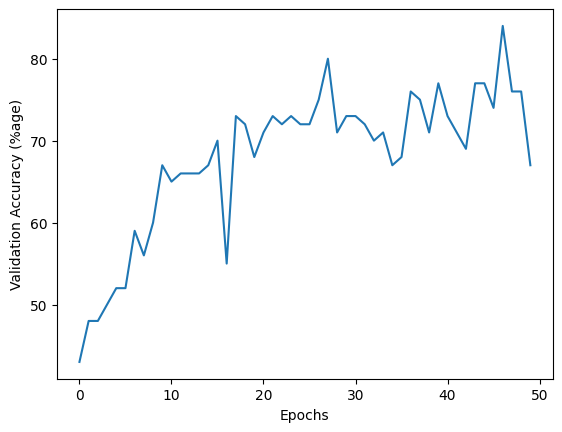

In [86]:
plt.plot(validation_accuracies)
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy (%age)")

Text(0, 0.5, 'Cross-Entropy Loss')

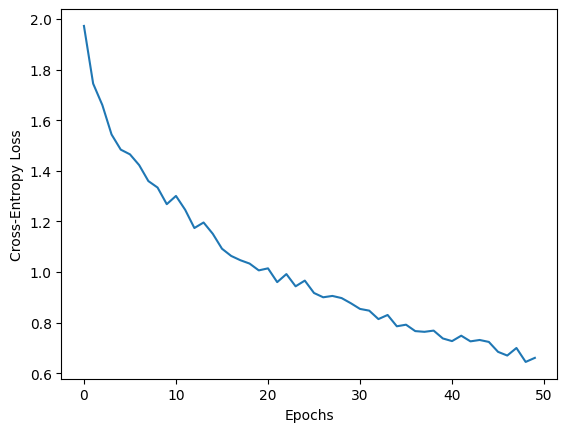

In [87]:
plt.plot(training_loss)
plt.xlabel("Epochs")
plt.ylabel("Cross-Entropy Loss")

In [88]:
loaded_model = ResNet()
loaded_model.load_state_dict(torch.load("resnetmodel.pth"))

C:\Users\Priyam Patel\AppData\Local\Temp\ipykernel_24396\1853803156.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load("resnetmodel.

<All keys matched successfully>

In [89]:
# final evaluation on test data
loaded_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for x, y in testloader:
        # x, y = x.to(device), y.to(device)
        outputs = loaded_model(x)
        _, predicted = torch.max(outputs.data, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

test_accuracy = 100 * correct / total
print("Test Acc (50 samples):", test_accuracy)
if test_accuracy > max_test_accuracy:
    print("SAVING MODEL")
    max_test_accuracy = test_accuracy
    torch.save(loaded_model.state_dict(), "final_resnetmodel.pth")


Test Acc (50 samples): 84.0
SAVING MODEL


In [90]:
final = ResNet()
final.load_state_dict(torch.load("final_resnetmodel.pth"))

C:\Users\Priyam Patel\AppData\Local\Temp\ipykernel_24396\417553165.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final.load_state_dict(torch.load("final_resnetmodel.pt

<All keys matched successfully>

In [99]:
# final evaluation on test data
final.eval()
correct = 0
total = 0
with torch.no_grad():
    for x, y in testloader:
        # x, y = x.to(device), y.to(device)
        outputs = final(x)
        _, predicted = torch.max(outputs.data, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

test_accuracy = 100 * correct / total
print("Test Acc (50 samples):", test_accuracy)
if test_accuracy > max_test_accuracy:
    print("SAVING MODEL")
    max_test_accuracy = test_accuracy
    torch.save(final.state_dict(), "final_resnetmodel.pth")


Test Acc (50 samples): 84.0
